In [18]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    RandomRotation,
    RandomZoom,
    RandomTranslation
)


In [2]:
# Set the main project directory to the parent
# of the current working directory
PROJECT_ROOT = Path.cwd().parent

# Create the path to the processed data directory
PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

# Create the path to the directory used for saved models
MODEL_DIR = (
    PROJECT_ROOT
    / "models"
)

# Create the path to the directory used for model results
RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)

# Create the models directory if it does not already exist
MODEL_DIR.mkdir(
    parents=True,   # Create any missing parent folders
    exist_ok=True   # Do not raise an error if it already exists
)

# Create the results directory if it does not already exist
RESULTS_DIR.mkdir(
    parents=True,   # Create any missing parent folders
    exist_ok=True   # Do not raise an error if it already exists
)

In [3]:
# Create the full path to the metadata file
# that contains the train, validation, and test split assignments
SPLIT_METADATA_FILE = (
    PROCESSED_DIR
    / "mri_metadata_split.csv"
)

# Load the split metadata CSV into a pandas DataFrame
df = pd.read_csv(
    SPLIT_METADATA_FILE
)

# Display the first five rows of the DataFrame
df.head()

,subject_id,class,slice_index,source_file,processed_file,original_shape,split
0,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control,35,/Users/paulcollingwood/Documents/Source/parkin...,/Users/paulcollingwood/Documents/Source/parkin...,"(91, 109, 91)",train
1,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control,40,/Users/paulcollingwood/Documents/Source/parkin...,/Users/paulcollingwood/Documents/Source/parkin...,"(91, 109, 91)",train
2,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control,45,/Users/paulcollingwood/Documents/Source/parkin...,/Users/paulcollingwood/Documents/Source/parkin...,"(91, 109, 91)",train
3,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control,50,/Users/paulcollingwood/Documents/Source/parkin...,/Users/paulcollingwood/Documents/Source/parkin...,"(91, 109, 91)",train
4,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control,55,/Users/paulcollingwood/Documents/Source/parkin...,/Users/paulcollingwood/Documents/Source/parkin...,"(91, 109, 91)",train


In [6]:
# Define the numeric label mapping
label_map = {
    "control": 0,
    "parkinsons": 1
}

# Create the numeric label column
df["label"] = (
    df["class"]
    .map(label_map)
)

# Check the mapping
print(
    df[
        [
            "class",
            "label"
        ]
    ]
    .drop_duplicates()
)

           class  label
0        control      0
1270  parkinsons      1


In [7]:
# Create the training DataFrame using only rows
# assigned to the training split
train_df = (
    df[
        df["split"] == "train"
    ]
    .reset_index(
        drop=True
    )
)

# Create the validation DataFrame using only rows
# assigned to the validation split
val_df = (
    df[
        df["split"] == "validation"
    ]
    .reset_index(
        drop=True
    )
)

# Create the test DataFrame using only rows
# assigned to the test split
test_df = (
    df[
        df["split"] == "test"
    ]
    .reset_index(
        drop=True
    )
)

In [8]:
# Display the number of MRI images in each dataset split
print(
    len(train_df),
    len(val_df),
    len(test_df)
)

1770 380 385


In [9]:
# Set the height of each MRI image used by the model
IMG_HEIGHT = 224

# Set the width of each MRI image used by the model
IMG_WIDTH = 224

# Set the number of MRI images processed in each batch
BATCH_SIZE = 16

In [10]:
# Define a function to load and prepare one MRI image
# together with its corresponding class label
def load_image(
    file_path,
    label
):
    # Read the PNG image file from disk
    image = tf.io.read_file(
        file_path
    )

    # Decode the PNG as a single-channel grayscale image
    image = tf.image.decode_png(
        image,
        channels=1
    )

    # Convert pixel values to 32-bit floating point
    # and scale them from 0–255 to 0–1
    image = tf.image.convert_image_dtype(
        image,
        tf.float32
    )

    # Resize the image to the dimensions expected by the model
    image = tf.image.resize(
        image,
        [
            IMG_HEIGHT,
            IMG_WIDTH
        ]
    )

    # Return the processed image together with its label
    return image, label

In [11]:
# Define a function to create a TensorFlow dataset
# from one of the metadata DataFrames
def create_dataset(
    dataframe,
    shuffle=False
):
    # Extract the processed MRI image file paths
    file_paths = (
        dataframe[
            "processed_file"
        ]
        .astype(str)
        .values
    )

    # Extract the numeric class labels
    # and convert them to 32-bit floating-point values
    labels = (
        dataframe[
            "label"
        ]
        .astype(
            np.float32
        )
        .values
    )

    # Create a TensorFlow dataset containing
    # pairs of image paths and labels
    dataset = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                file_paths,
                labels
            )
        )
    )

    # Load and preprocess each MRI image
    dataset = dataset.map(
        load_image,
        num_parallel_calls=(
            tf.data.AUTOTUNE
        )
    )

    # Shuffle the dataset when requested
    # This should normally be used for the training set
    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(
                dataframe
            ),
            seed=42
        )

    # Group the images into batches
    dataset = dataset.batch(
        BATCH_SIZE
    )

    # Prepare upcoming batches in the background
    # while the current batch is being processed
    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    # Return the completed TensorFlow dataset
    return dataset

In [12]:
# Create the training TensorFlow dataset
# and enable shuffling so images are presented
# in a different order during training
train_dataset = create_dataset(
    train_df,
    shuffle=True
)

# Create the validation TensorFlow dataset
# without shuffling
val_dataset = create_dataset(
    val_df
)

# Create the test TensorFlow dataset
# without shuffling
test_dataset = create_dataset(
    test_df
)

In [13]:
# Create a data augmentation pipeline to introduce
# small random variations during training
data_augmentation = Sequential([

    # Apply a small random rotation to the MRI image
    RandomRotation(
        0.03
    ),

    # Apply a small random zoom
    RandomZoom(
        0.05
    ),

    # Apply a small random vertical and horizontal shift
    RandomTranslation(
        height_factor=0.03,
        width_factor=0.03
    )
])

In [14]:
# Take one batch from the training dataset
for images, labels in (
    train_dataset.take(1)
):

    # Select the first MRI image from the batch
    # so it can be used to test the data augmentation pipeline
    example_image = (
        images[0]
    )

    # Stop after retrieving the first batch
    break

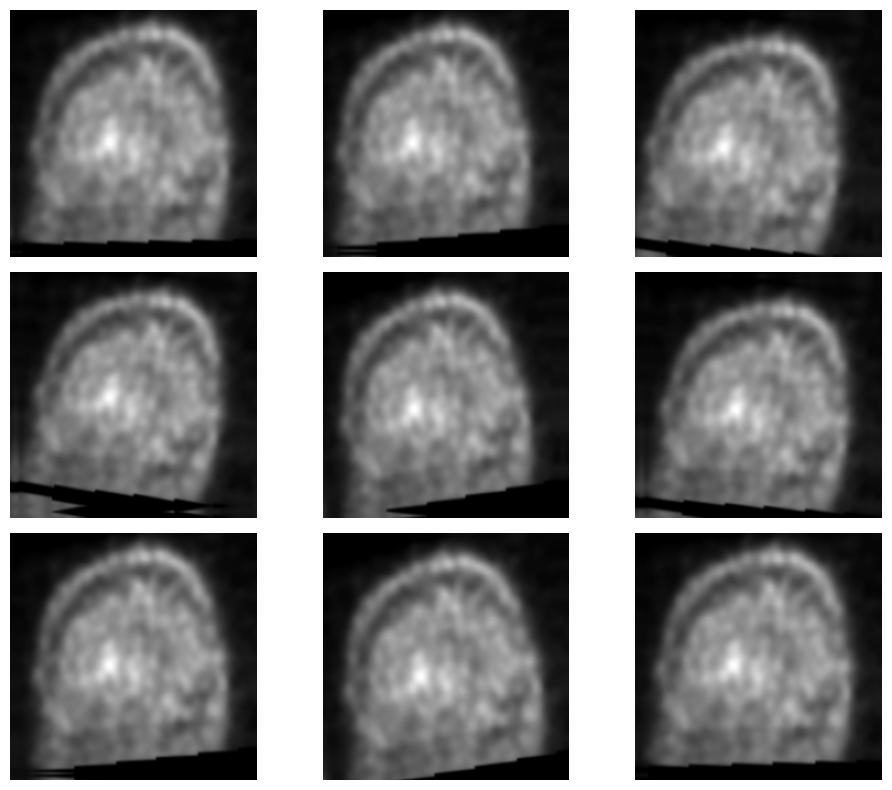

In [15]:
# Create a figure to display several augmented
# versions of the same MRI image
plt.figure(
    figsize=(10, 8)
)

# Generate and display 9 augmented versions
# of the selected training image
for i in range(9):

    # Add a batch dimension to the single MRI image
    # and apply random augmentation
    augmented = (
        data_augmentation(
            tf.expand_dims(
                example_image,
                axis=0
            ),
            training=True
        )
    )

    # Create a 3 x 3 grid of subplots
    plt.subplot(
        3,
        3,
        i + 1
    )

    # Display the augmented MRI image in grayscale
    plt.imshow(
        augmented[0]
        .numpy()
        .squeeze(),
        cmap="gray"
    )

    # Hide the axis labels and tick marks
    plt.axis("off")

# Adjust spacing between the augmented images
plt.tight_layout()

# Display the augmentation examples
plt.show()

In [19]:
# Convert the multi-dimensional feature maps into a one-dimensional vector
Flatten()

<Flatten name=flatten, built=False>

In [20]:
# Reduce each feature map to a single average value
# to create a compact feature vector before the Dense layers
GlobalAveragePooling2D()

<GlobalAveragePooling2D name=global_average_pooling2d, built=True>

In [21]:
# Create an improved CNN model
improved_model = Sequential([

    # Define the expected input shape:
    # 224 x 224 pixels with 1 grayscale channel
    Input(
        shape=(
            IMG_HEIGHT,
            IMG_WIDTH,
            1
        )
    ),

    # Apply small random transformations during training
    # to help the model generalise better
    data_augmentation,

    # First convolutional block
    Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    # Normalise activations to improve training stability
    BatchNormalization(),

    # Reduce the spatial dimensions
    MaxPooling2D(
        (2, 2)
    ),

    # Second convolutional block
    Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    BatchNormalization(),

    MaxPooling2D(
        (2, 2)
    ),

    # Third convolutional block
    Conv2D(
        128,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    BatchNormalization(),

    MaxPooling2D(
        (2, 2)
    ),

    # Fourth convolutional block
    # learns more complex image features
    Conv2D(
        256,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    BatchNormalization(),

    # Reduce each feature map to one average value
    # instead of using a large Flatten layer
    GlobalAveragePooling2D(),

    # Fully connected layer for classification
    Dense(
        128,
        activation="relu"
    ),

    # Randomly deactivate 50% of neurons during training
    # to help reduce overfitting
    Dropout(
        0.5
    ),

    # Final binary classification output
    # 0 = Control, 1 = Parkinson's
    Dense(
        1,
        activation="sigmoid"
    )
])

In [22]:
# Display a summary of the improved CNN architecture,
# including each layer, output shape, and parameter count
improved_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,785 (1.61 MB)

 Trainable params: 421,825 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [23]:
# Reduce each feature map to a single average value,
# creating a compact feature vector before the Dense layers
GlobalAveragePooling2D()

<GlobalAveragePooling2D name=global_average_pooling2d_2, built=True>

In [24]:
# Compile the improved CNN model
improved_model.compile(

    # Use the Adam optimiser with an explicit learning rate
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    # Use binary cross-entropy because this is
    # a two-class classification problem
    loss="binary_crossentropy",

    # Track several performance metrics during training
    metrics=[

        # Overall proportion of correct predictions
        "accuracy",

        # Proportion of predicted Parkinson's cases
        # that are actually Parkinson's
        tf.keras.metrics.Precision(
            name="precision"
        ),

        # Proportion of actual Parkinson's cases
        # correctly identified by the model
        tf.keras.metrics.Recall(
            name="recall"
        ),

        # Measure how well the model separates
        # Parkinson's and control cases across thresholds
        tf.keras.metrics.AUC(
            name="auc"
        )
    ]
)

In [25]:
# Create an EarlyStopping callback to reduce overfitting
early_stopping = (
    tf.keras.callbacks
    .EarlyStopping(

        # Monitor the validation loss after each epoch
        monitor="val_loss",

        # Stop training if validation loss does not improve
        # for 7 consecutive epochs
        patience=7,

        # Restore the weights from the epoch
        # with the best validation loss
        restore_best_weights=True
    )
)

In [26]:
# Create a callback that automatically reduces the learning rate
# when the validation loss stops improving
reduce_lr = (
    tf.keras.callbacks
    .ReduceLROnPlateau(

        # Monitor the validation loss after each epoch
        monitor="val_loss",

        # Multiply the current learning rate by 0.5
        # when improvement has stalled
        factor=0.5,

        # Wait 3 epochs without improvement
        # before reducing the learning rate
        patience=3,

        # Do not allow the learning rate to fall below 0.000001
        min_lr=1e-6,

        # Display a message whenever the learning rate is reduced
        verbose=1
    )
)

In [27]:
# Set the maximum number of training epochs
EPOCHS = 40

In [28]:
# Train the improved CNN using the training dataset
improved_history = (
    improved_model.fit(

        # Dataset used to update the model weights
        train_dataset,

        # Dataset used to evaluate performance
        # after each training epoch
        validation_data=(
            val_dataset
        ),

        # Maximum number of training epochs
        epochs=EPOCHS,

        # Use EarlyStopping and ReduceLROnPlateau
        # during training
        callbacks=[
            early_stopping,
            reduce_lr
        ]
    )
)

Epoch 1/40


/Users/paulcollingwood/Documents/Source/parkinsons_ml/.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


111/111 ━━━━━━━━━━━━━━━━━━━━ 27s 229ms/step - accuracy: 0.7198 - auc: 0.7854 - loss: 0.5781 - precision: 0.7286 - recall: 0.7006 - val_accuracy: 0.5000 - val_auc: 0.6422 - val_loss: 2.6759 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/40
111/111 ━━━━━━━━━━━━━━━━━━━━ 25s 224ms/step - accuracy: 0.7243 - auc: 0.8039 - loss: 0.5458 - precision: 0.7338 - recall: 0.7040 - val_accuracy: 0.5000 - val_auc: 0.7034 - val_loss: 2.2875 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/40
111/111 ━━━━━━━━━━━━━━━━━━━━ 25s 228ms/step - accuracy: 0.7311 - auc: 0.8040 - loss: 0.5435 - precision: 0.7240 - recall: 0.7469 - val_accuracy: 0.5000 - val_auc: 0.7728 - val_loss: 1.4051 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/40
111/111 ━━━━━━━━━━━━━━━━━━━━ 26s 234ms/step - accuracy: 0.7362 - auc: 0.7985 - loss: 0.5514 - precision: 0.7242 - recall: 0.7627 - val_accuracy: 0.5000 - val_auc: 0.7399

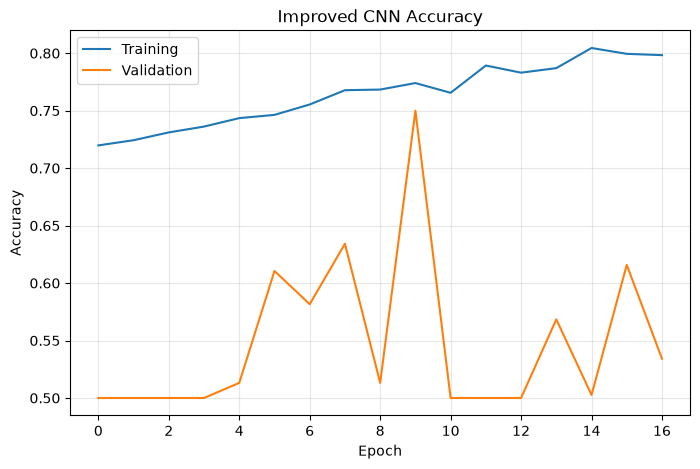

In [29]:
# Create a figure for plotting the improved model's
# training and validation accuracy
plt.figure(
    figsize=(8, 5)
)

# Plot the training accuracy for each epoch
plt.plot(
    improved_history.history[
        "accuracy"
    ],
    label="Training"
)

# Plot the validation accuracy for each epoch
plt.plot(
    improved_history.history[
        "val_accuracy"
    ],
    label="Validation"
)

# Label the horizontal axis
plt.xlabel("Epoch")

# Label the vertical axis
plt.ylabel("Accuracy")

# Add a title to the graph
plt.title(
    "Improved CNN Accuracy"
)

# Display the legend
plt.legend()

# Add a light grid to make the graph easier to read
plt.grid(
    alpha=0.3
)

# Display the graph
plt.show()

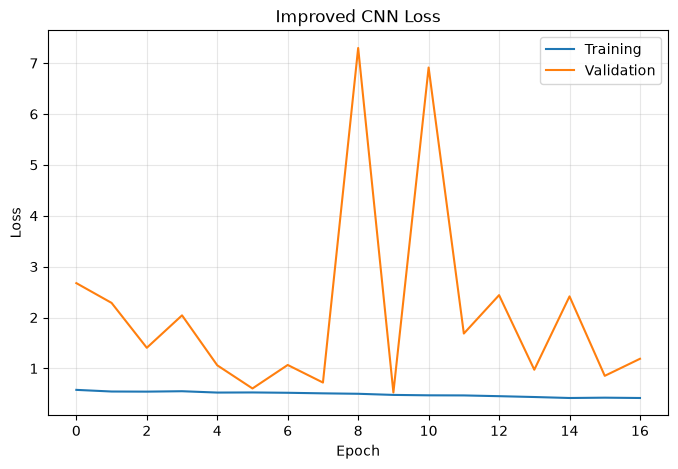

In [30]:
# Create a figure for plotting the improved model's
# training and validation loss
plt.figure(
    figsize=(8, 5)
)

# Plot the training loss for each epoch
plt.plot(
    improved_history.history[
        "loss"
    ],
    label="Training"
)

# Plot the validation loss for each epoch
plt.plot(
    improved_history.history[
        "val_loss"
    ],
    label="Validation"
)

# Label the horizontal axis
plt.xlabel("Epoch")

# Label the vertical axis
plt.ylabel("Loss")

# Add a title to the graph
plt.title(
    "Improved CNN Loss"
)

# Display the legend
plt.legend()

# Add a light grid to make the graph easier to read
plt.grid(
    alpha=0.3
)

# Display the graph
plt.show()

In [31]:
# Evaluate the improved CNN using the test dataset
improved_test_results = (
    improved_model.evaluate(
        test_dataset,
        verbose=1
    )
)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.8234 - auc: 0.9158 - loss: 0.3768 - precision: 0.8050 - recall: 0.8474


In [32]:
# Display the raw test evaluation results
# returned by the improved CNN
print(
    improved_test_results
)

[0.37684130668640137, 0.8233765959739685, 0.8050000071525574, 0.8473684191703796, 0.9158299565315247]


In [33]:
# Use the improved CNN to predict the probability
# of Parkinson's for every image in the test dataset
improved_probabilities = (
    improved_model.predict(
        test_dataset
    )

    # Convert the output from shape (n, 1)
    # into a one-dimensional NumPy array
    .flatten()
)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step


In [34]:
# Convert the improved model's predicted probabilities
# into binary class predictions
improved_predictions = (
    improved_probabilities
    >= 0.5
).astype(int)

In [35]:
# Extract the true class labels from the test DataFrame
true_labels = (
    test_df[
        "label"
    ]

    # Convert the labels to integer values
    .astype(int)

    # Convert the pandas Series into a NumPy array
    .values
)

In [36]:
# Calculate the overall slice-level accuracy
slice_accuracy = (
    accuracy_score(
        true_labels,
        improved_predictions
    )
)

# Calculate slice-level precision
# This measures how many slices predicted as Parkinson's
# were actually Parkinson's
slice_precision = (
    precision_score(
        true_labels,
        improved_predictions,
        zero_division=0
    )
)

# Calculate slice-level recall
# This measures how many actual Parkinson's slices
# were correctly identified by the model
slice_recall = (
    recall_score(
        true_labels,
        improved_predictions,
        zero_division=0
    )
)

# Calculate the slice-level F1-score
# This combines precision and recall into one measure
slice_f1 = (
    f1_score(
        true_labels,
        improved_predictions,
        zero_division=0
    )
)

# Calculate the ROC AUC score using the predicted probabilities
# rather than the final 0/1 class predictions
slice_auc = (
    roc_auc_score(
        true_labels,
        improved_probabilities
    )
)

In [37]:
# Display the improved CNN's slice-level accuracy
print(
    f"Accuracy:  {slice_accuracy:.4f}"
)

# Display the slice-level precision
print(
    f"Precision: {slice_precision:.4f}"
)

# Display the slice-level recall
print(
    f"Recall:    {slice_recall:.4f}"
)

# Display the slice-level F1-score
print(
    f"F1:        {slice_f1:.4f}"
)

# Display the slice-level ROC-AUC score
print(
    f"ROC-AUC:   {slice_auc:.4f}"
)

Accuracy:  0.8234
Precision: 0.8050
Recall:    0.8474
F1:        0.8256
ROC-AUC:   0.9157


In [38]:
# Generate and display a classification report
# for the improved CNN at slice level
print(
    classification_report(
        true_labels,
        improved_predictions,

        # Display readable class names instead of 0 and 1
        target_names=[
            "Control",
            "Parkinson's"
        ]
    )
)

              precision    recall  f1-score   support

     Control       0.84      0.80      0.82       195
 Parkinson's       0.81      0.85      0.83       190

    accuracy                           0.82       385
   macro avg       0.82      0.82      0.82       385
weighted avg       0.82      0.82      0.82       385



In [39]:
# Create the confusion matrix for the improved CNN
# by comparing the true test labels with the predicted labels
improved_cm = (
    confusion_matrix(
        true_labels,
        improved_predictions
    )
)

# Display the confusion matrix
print(
    improved_cm
)

[[156  39]
 [ 29 161]]


In [40]:
# Extract the true negatives, false positives,
# false negatives, and true positives
tn, fp, fn, tp = (
    improved_cm.ravel()
)

# Calculate sensitivity
# This is the proportion of actual Parkinson's cases
# correctly identified by the improved CNN
sensitivity = (
    tp / (
        tp + fn
    )
)

# Calculate specificity
# This is the proportion of actual control cases
# correctly identified by the improved CNN
specificity = (
    tn / (
        tn + fp
    )
)

# Display the sensitivity
print(
    f"Sensitivity: "
    f"{sensitivity:.4f}"
)

# Display the specificity
print(
    f"Specificity: "
    f"{specificity:.4f}"
)

Sensitivity: 0.8474
Specificity: 0.8000


In [41]:
# Create a copy of the test DataFrame
# so the original test metadata remains unchanged
test_results_df = (
    test_df.copy()
)

# Add the improved CNN's predicted Parkinson's
# probability for each MRI slice
test_results_df[
    "probability"
] = (
    improved_probabilities
)

In [42]:
# Group the slice-level predictions by subject
# so that each subject receives one combined probability
subject_predictions = (
    test_results_df
    .groupby(
        [
            "subject_id",
            "class",
            "label"
        ]
    )

    # Calculate the average predicted probability
    # across all MRI slices belonging to each subject
    .agg(
        mean_probability=(
            "probability",
            "mean"
        )
    )

    # Convert the grouped index back into normal DataFrame columns
    .reset_index()
)

In [43]:
# Convert each subject's average predicted probability
# into a final binary class prediction
subject_predictions[
    "prediction"
] = (
    subject_predictions[
        "mean_probability"
    ]
    >= 0.5
).astype(int)

In [44]:
# Display the first five subject-level predictions
subject_predictions.head()

,subject_id,class,label,mean_probability,prediction
0,PPMI_102447_NM_Reconstructed_DaTSCAN_Br_202110...,control,0,0.234246,0
1,PPMI_116231_NM_Reconstructed_DaTSCAN_Br_202112...,control,0,0.272689,0
2,PPMI_118726_NM_Reconstructed_DaTSCAN_Br_202201...,control,0,0.256535,0
3,PPMI_128335_NM_Reconstructed_DaTSCAN_Br_202201...,control,0,0.156173,0
4,PPMI_138022_NM_Reconstructed_DaTSCAN_Br_202204...,control,0,0.142647,0


In [45]:
# Calculate the overall subject-level accuracy
subject_accuracy = (
    accuracy_score(
        subject_predictions[
            "label"
        ],
        subject_predictions[
            "prediction"
        ]
    )
)

# Display the subject-level accuracy
# rounded to 4 decimal places
print(
    f"Subject-level accuracy: "
    f"{subject_accuracy:.4f}"
)

Subject-level accuracy: 0.8961


In [46]:
# Generate and display a subject-level classification report
# for the improved CNN
print(
    classification_report(
        subject_predictions[
            "label"
        ],
        subject_predictions[
            "prediction"
        ],

        # Display readable class names instead of 0 and 1
        target_names=[
            "Control",
            "Parkinson's"
        ]
    )
)

              precision    recall  f1-score   support

     Control       0.88      0.92      0.90        39
 Parkinson's       0.92      0.87      0.89        38

    accuracy                           0.90        77
   macro avg       0.90      0.90      0.90        77
weighted avg       0.90      0.90      0.90        77



In [47]:
# Create a subject-level confusion matrix by comparing
# the true subject labels with the final subject predictions
subject_cm = (
    confusion_matrix(
        subject_predictions[
            "label"
        ],
        subject_predictions[
            "prediction"
        ]
    )
)

# Display the subject-level confusion matrix
print(
    subject_cm
)

[[36  3]
 [ 5 33]]


In [48]:
# Create the full path for saving the improved CNN model
IMPROVED_MODEL_FILE = (
    MODEL_DIR
    / "improved_mri_cnn.keras"
)

# Save the complete improved Keras model to disk
# This includes the architecture, trained weights,
# and compile configuration
improved_model.save(
    IMPROVED_MODEL_FILE
)

# Display the location of the saved model file
print(
    IMPROVED_MODEL_FILE
)

/Users/paulcollingwood/Documents/Source/parkinsons_ml/models/improved_mri_cnn.keras


In [49]:
# Convert the improved CNN training history
# into a pandas DataFrame
improved_history_df = (
    pd.DataFrame(
        improved_history.history
    )
)

# Create the full path for the improved
# model training history CSV file
history_file = (
    RESULTS_DIR
    / "improved_cnn_history.csv"
)

# Save the epoch-by-epoch training history
# without including the DataFrame index
improved_history_df.to_csv(
    history_file,
    index=False
)

# Display the location of the saved history file
print(
    history_file
)

/Users/paulcollingwood/Documents/Source/parkinsons_ml/results/improved_cnn_history.csv


In [50]:
# Load the saved baseline CNN training history
# from the CSV file created earlier
baseline_history = (
    pd.read_csv(
        PROCESSED_DIR
        / "baseline_training_history.csv"
    )
)

# Display the first five rows of the baseline training history
baseline_history.head()

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall
0,0.881356,0.944180,0.297493,0.902265,0.855367,0.813158,0.910983,0.397292,0.883871,0.721053
1,0.884746,0.952666,0.275859,0.900118,0.865537,0.818421,0.905720,0.410477,0.911565,0.705263
2,0.896610,0.961238,0.246518,0.916865,0.872316,0.818421,0.918449,0.390279,0.895425,0.721053
3,0.910734,0.967387,0.228990,0.927145,0.891525,0.818421,0.908837,0.442553,0.875776,0.742105
4,0.922034,0.976655,0.197233,0.938895,0.902825,0.828947,0.913089,0.398614,0.865497,0.778947


In [51]:
# Display the highest validation accuracy achieved
# by the baseline CNN during training
print(
    "Baseline best validation accuracy:",
    baseline_history[
        "val_accuracy"
    ].max()
)

# Display the highest validation accuracy achieved
# by the improved CNN during training
print(
    "Improved best validation accuracy:",
    improved_history_df[
        "val_accuracy"
    ].max()
)

Baseline best validation accuracy: 0.8315789699554443
Improved best validation accuracy: 0.75


In [52]:
# Create a comparison DataFrame containing the
# main evaluation metrics for the improved CNN
comparison = pd.DataFrame([
    {
        # Name of the model being evaluated
        "model":
            "Improved CNN",

        # Slice-level overall accuracy
        "slice_accuracy":
            slice_accuracy,

        # Slice-level precision
        "slice_precision":
            slice_precision,

        # Slice-level recall
        "slice_recall":
            slice_recall,

        # Slice-level F1-score
        "slice_f1":
            slice_f1,

        # Slice-level ROC-AUC score
        "slice_auc":
            slice_auc,

        # Subject-level overall accuracy
        "subject_accuracy":
            subject_accuracy,

        # Sensitivity for detecting Parkinson's cases
        "sensitivity":
            sensitivity,

        # Specificity for correctly identifying controls
        "specificity":
            specificity
    }
])

# Display the model comparison table
comparison

,model,slice_accuracy,slice_precision,slice_recall,slice_f1,slice_auc,subject_accuracy,sensitivity,specificity
0,Improved CNN,0.823377,0.805,0.847368,0.825641,0.915735,0.896104,0.847368,0.8


In [53]:
# Save the improved CNN comparison results
# as a CSV file inside the results directory
comparison.to_csv(
    RESULTS_DIR
    / "improved_cnn_results.csv",
    index=False   # Do not save the DataFrame row numbers
)